            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340
Number of points: 1500


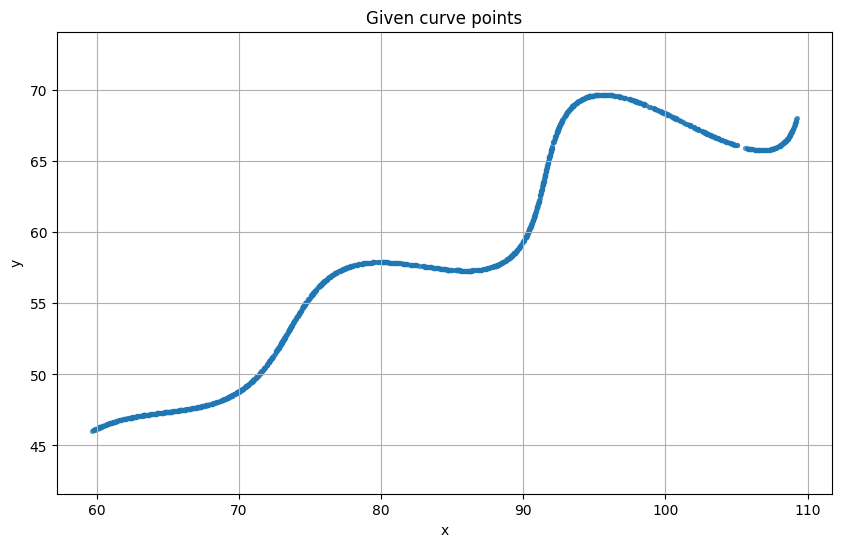

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("/content/xy_data.csv")

print(data.head())
print("Number of points:", len(data))

plt.figure(figsize=(10, 6))
plt.scatter(data["x"], data["y"], s=8, alpha=0.6)
plt.title("Given curve points")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.axis("equal")
plt.show()

The curve starts near the lower-left and generally moves up and right.
It has a repeating wobble rather than a straight-line shape.
The wobble changes size along the curve.
The points are dense enough that they appear almost like a continuous line.
The whole curve is shifted away from \((0, 0)\), so an \(X\) shift makes sense.

In [27]:
import numpy as np

def curve(t, theta, M, X):
    x = (
        t * np.cos(theta)
        - np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.sin(theta)
        + X
    )

    y = (
        42
        + t * np.sin(theta)
        + np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.cos(theta)
    )

    return x, y

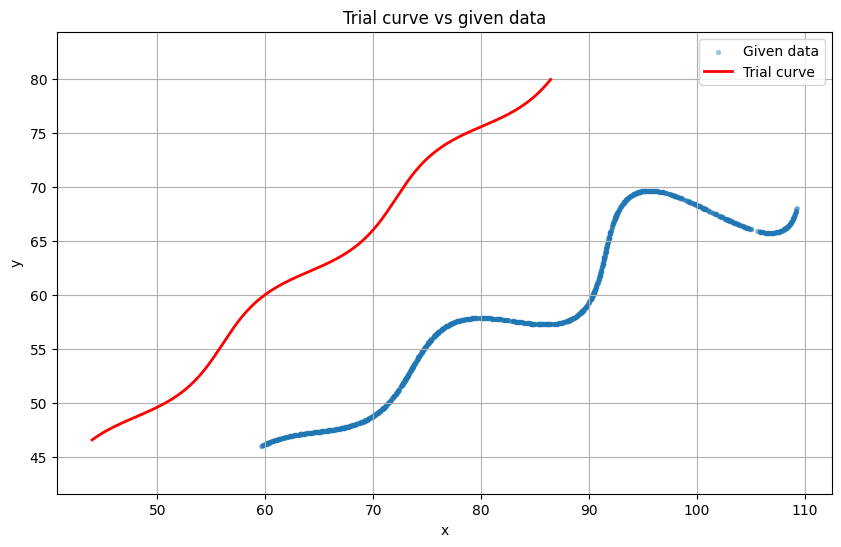

In [28]:
t = np.linspace(6, 60, 1500)

# These are deliberately only trial values
theta = np.deg2rad(40)
M = 0.0
X = 40

x_test, y_test = curve(t, theta, M, X)

plt.figure(figsize=(10, 6))
plt.scatter(data["x"], data["y"], s=8, alpha=0.35, label="Given data")
plt.plot(x_test, y_test, color="red", linewidth=2, label="Trial curve")

plt.title("Trial curve vs given data")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

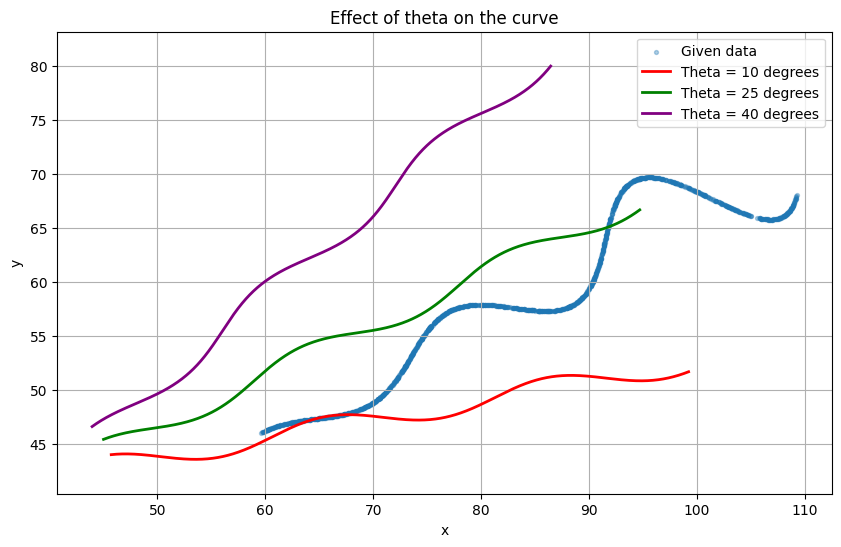

In [29]:
t = np.linspace(6, 60, 1500)

M = 0.0
X = 40

theta_values = [10, 25, 40]
colors = ["red", "green", "purple"]

plt.figure(figsize=(10, 6))
plt.scatter(data["x"], data["y"], s=8, alpha=0.35, label="Given data")

for degree, color in zip(theta_values, colors):
    theta = np.deg2rad(degree)
    x_test, y_test = curve(t, theta, M, X)

    plt.plot(
        x_test,
        y_test,
        color=color,
        linewidth=2,
        label=f"Theta = {degree} degrees"
    )

plt.title("Effect of theta on the curve")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

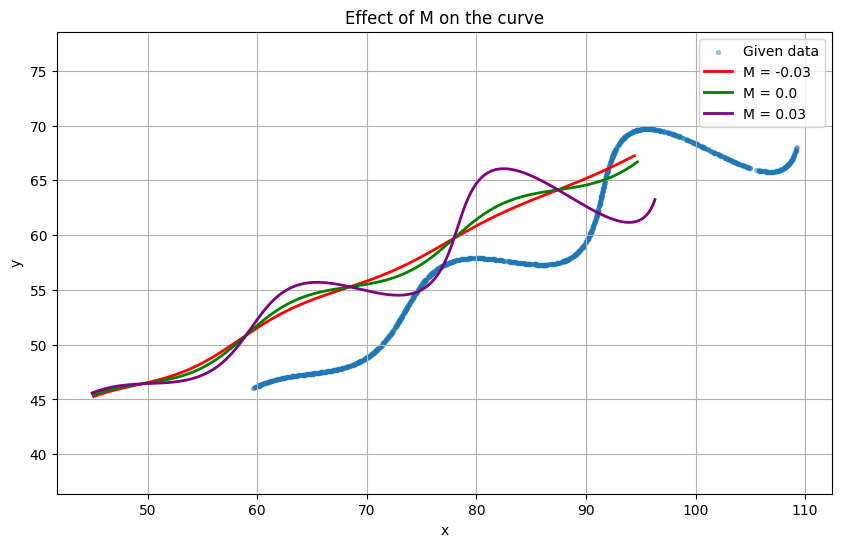

In [30]:
t = np.linspace(6, 60, 1500)

theta = np.deg2rad(25)
X = 40

M_values = [-0.03, 0.0, 0.03]
colors = ["red", "green", "purple"]

plt.figure(figsize=(10, 6))
plt.scatter(data["x"], data["y"], s=8, alpha=0.35, label="Given data")

for M, color in zip(M_values, colors):
    x_test, y_test = curve(t, theta, M, X)

    plt.plot(
        x_test,
        y_test,
        color=color,
        linewidth=2,
        label=f"M = {M}"
    )

plt.title("Effect of M on the curve")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

M = -0.03: the wobble should become smaller toward the end.
M = 0: wobble size stays more consistent.
M = 0.03: the wobble grows toward the end.

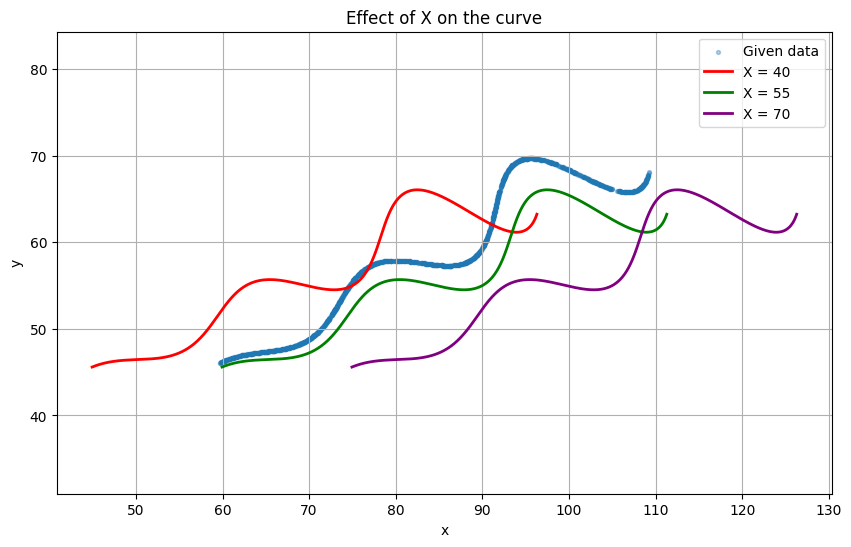

In [31]:
t = np.linspace(6, 60, 1500)

theta = np.deg2rad(25)
M = 0.03

X_values = [40, 55, 70]
colors = ["red", "green", "purple"]

plt.figure(figsize=(10, 6))
plt.scatter(data["x"], data["y"], s=8, alpha=0.35, label="Given data")

for X, color in zip(X_values, colors):
    x_test, y_test = curve(t, theta, M, X)

    plt.plot(
        x_test,
        y_test,
        color=color,
        linewidth=2,
        label=f"X = {X}"
    )

plt.title("Effect of X on the curve")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

Changing X moves the complete predicted curve left or right along the x-axis. It does not alter the curve’s angle or the size of its oscillations.

In [32]:
trial_1 = [np.deg2rad(25), 0.03, 55]
trial_2 = [np.deg2rad(10), 0.00, 40]
trial_3 = [np.deg2rad(40), -0.03, 70]

print("Trial 1 loss:", loss_function(trial_1, data))
print("Trial 2 loss:", loss_function(trial_2, data))
print("Trial 3 loss:", loss_function(trial_3, data))

Trial 1 loss: 2.878054371053687
Trial 2 loss: 8.393194886228322
Trial 3 loss: 4.762751014975858


Trial 1: 2.878 — best of the three.
Trial 3: 4.763 — worse.
Trial 2: 8.393 — much worse.

In [33]:
def loss_function(params, data):
    theta, M, X = params

    x = data["x"].to_numpy()
    y = data["y"].to_numpy()

    u = (x - X) * np.cos(theta) + (y - 42) * np.sin(theta)
    v = -(x - X) * np.sin(theta) + (y - 42) * np.cos(theta)

    w_model = np.exp(M * np.abs(u)) * np.sin(0.3 * u)

    return np.mean(np.abs(v - w_model))

In [34]:

from scipy.optimize import differential_evolution


bounds = [
    (0, np.deg2rad(50)),
    (-0.05, 0.05),
    (0, 100)
]

result = differential_evolution(
    loss_function,
    bounds,
    args=(data,),
    seed=42,
    tol=1e-8,
    polish=True
)

print("Success:", result.success)
print("Best parameters:", result.x)
print("Final loss:", result.fun)

Success: True
Best parameters: [5.23598304e-01 2.99999971e-02 5.49999983e+01]
Final loss: 2.558593121152109e-06


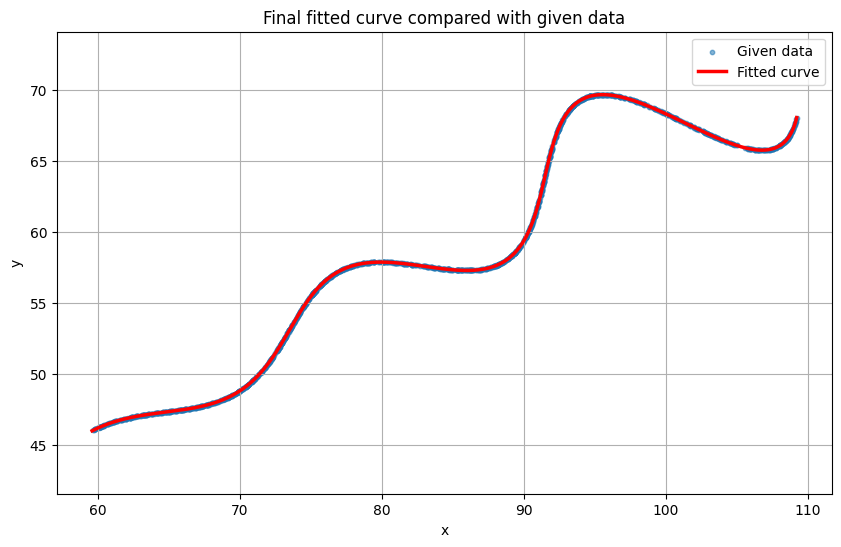

In [35]:
theta_fit, M_fit, X_fit = result.x

t = np.linspace(6, 60, 1500)
x_fit, y_fit = curve(t, theta_fit, M_fit, X_fit)

plt.figure(figsize=(10, 6))
plt.scatter(data["x"], data["y"], s=10, alpha=0.55, label="Given data")
plt.plot(x_fit, y_fit, color="red", linewidth=2.5, label="Fitted curve")

plt.title("Final fitted curve compared with given data")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

In [36]:
print(f"Theta: {np.rad2deg(theta_fit):.4f} degrees")
print(f"M: {M_fit:.6f}")
print(f"X: {X_fit:.4f}")
print(f"Mean absolute error: {result.fun:.8f}")

Theta: 30.0000 degrees
M: 0.030000
X: 55.0000
Mean absolute error: 0.00000256


I visualized the unordered curve points and studied how theta, M, and X change the generated curve. I transformed observed points into rotated coordinates so that the position along the curve could be estimated directly, avoiding nearest-point matching. I minimized mean absolute error using differential evolution within the given parameter ranges. The final estimates were theta = 30 degrees, M = 0.03, and X = 55. The final error was approximately \(2.56 \times 10^{-6}\), and the fitted curve closely overlapped the provided data.